# 음성의 기본 표현 및 librosa 실습 진행
## 2026-09-29

In [2]:
# 처음에 실행해서, 관련 패키지를 설치합니다.
%pip install librosa matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import scipy.signal as sps
import matplotlib as mpl
import matplotlib.pyplot as plt

import librosa
import librosa.display
from IPython.display import Audio, display

print("librosa 버전:", librosa.__version__)
print("numpy  버전:", np.__version__)

mpl.rcParams["font.family"] = ["Malgun Gothic","DejaVu Sans"]
mpl.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지
mpl.rcParams["figure.figsize"] = (11, 3.5)
mpl.rcParams["figure.max_open_warning"] = 0
print("사용 폰트:", mpl.rcParams["font.family"])

librosa 버전: 1.0.0
numpy  버전: 2.5.3
사용 폰트: ['Malgun Gothic', 'DejaVu Sans']


In [4]:
# ── 오늘 사용할 음성 파일 ─────────────────────────────────────────────
# 방법 A: librosa 내장 예제 (영어 낭독 음성, 인터넷 필요)
# 방법 B: 직접 녹음한 wav 파일 경로를 AUDIO_PATH 에 적기  (권장! 자기 목소리가 제일 재미있습니다)
# 방법 C: 인터넷이 안 되면 맨 아래 [부록 A]의 합성 음성 코드를 먼저 실행

AUDIO_PATH = None          # 예: AUDIO_PATH = "my_voice.wav"
SR = 16000                 # 광대역 음성 표준

if AUDIO_PATH:
    y, sr = librosa.load(AUDIO_PATH, sr=SR, mono=True)
else:
    y, sr = librosa.load(librosa.example("libri1"), sr=SR, mono=True)

y = y[:int(4.0 * sr)]      # 너무 길면 앞 4초만 사용

print("y 타입      :", type(y))
print("y shape     :", y.shape, "  ← 샘플 개수")
print("y dtype     :", y.dtype, " ← 실수(float32), 보통 -1.0 ~ +1.0 범위")
print("sr          :", sr, "Hz")
print("길이        : %.2f 초" % librosa.get_duration(y=y, sr=sr))
print("샘플 수 검산: %d x %.2f = %.0f" % (sr, len(y)/sr, len(y)))
print("최대 진폭   : %.3f" % np.max(np.abs(y)))
print("\ny 의 앞 10개 값:", np.round(y[:10], 4))

y 타입      : <class 'numpy.ndarray'>
y shape     : (64000,)   ← 샘플 개수
y dtype     : float32  ← 실수(float32), 보통 -1.0 ~ +1.0 범위
sr          : 16000 Hz
길이        : 4.00 초
샘플 수 검산: 16000 x 4.00 = 64000
최대 진폭   : 0.779

y 의 앞 10개 값: [0.0003 0.0003 0.0002 0.0002 0.0001 0.0002 0.0001 0.0002 0.0001 0.0002]


In [6]:
#display(Audio(data=y, rate=sr))
Audio(data=y, rate=sr)  

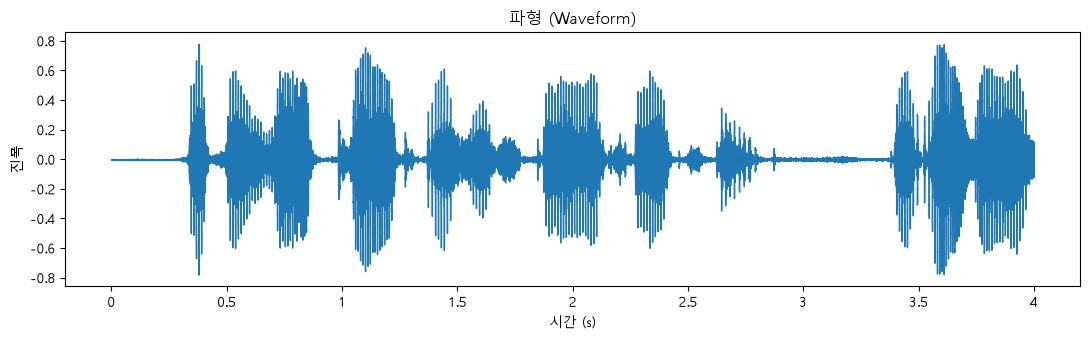

In [7]:
# 파형 그리기 — 교재 2.1의 첫 그림과 같은 것
fig, ax = plt.subplots()
librosa.display.waveshow(y, sr=sr, ax=ax)
ax.set(title="파형 (Waveform)", xlabel="시간 (s)", ylabel="진폭")
plt.tight_layout(); plt.show()

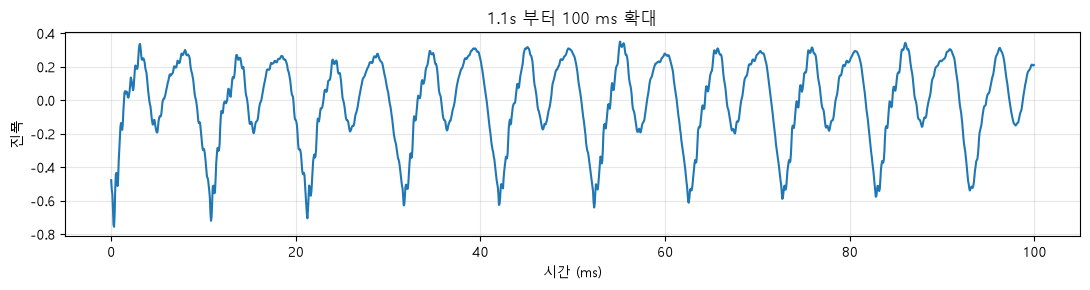

In [11]:
# start, dur = 1.0, 0.05          # ← 값을 바꿔가며 관찰해 보세요
start, dur = map(float, input("시작 구간 (초)").split())
seg = y[int(start*sr):int((start+dur)*sr)]

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(np.arange(len(seg))/sr*1000, seg)
ax.set(title=f"{start}s 부터 {dur*1000:.0f} ms 확대", xlabel="시간 (ms)", ylabel="진폭")
ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 샘플링 레이트 비교

In [17]:
for target in [16000, 8000, 4000]:
    y_rs = librosa.resample(y, orig_sr=sr, target_sr=target)
    print(f"Fs = {target:5d} Hz   나이퀴스트 = {target//2:5d} Hz   샘플 수 = {len(y_rs):6d}")
    display(Audio(data=y_rs, rate=target))

# 2000Hz 음성은 다시 16000Hz로 업샘플링해서 청취
target = 2000
y_rs = librosa.resample(y, orig_sr=sr, target_sr=target)
print(f"Fs = {target:5d} Hz   나이퀴스트 = {target//2:5d} Hz   샘플 수 = {len(y_rs):6d}")
y_play = librosa.resample(y_rs, orig_sr=target, target_sr=sr)
display(Audio(data=y_play, rate=sr))

Fs = 16000 Hz   나이퀴스트 =  8000 Hz   샘플 수 =  64000


Fs =  8000 Hz   나이퀴스트 =  4000 Hz   샘플 수 =  32000


Fs =  4000 Hz   나이퀴스트 =  2000 Hz   샘플 수 =  16000


Fs =  2000 Hz   나이퀴스트 =  1000 Hz   샘플 수 =   8000


## 진폭 양자화 비교

In [18]:
# 선형 양자화: x를 2^bits 단계로 반올림 (교재 2.1.4)
def linear_quantize(x, bits):
    levels = 2 ** (bits - 1)          # 부호 있는 정수 범위의 절반
    dq = 1.0 / levels                 # 양자화 스텝 크기 Δq
    return np.clip(np.round(x / dq) * dq, -1.0, 1.0)


# 원본 대비 양자화 오차의 신호대잡음비(dB)
def snr_db(x, x_hat):
    noise = x - x_hat
    return 10 * np.log10(np.sum(x**2) / (np.sum(noise**2) + 1e-20))


for bits in [16, 8, 6, 4, 3, 2]:
    yq = linear_quantize(y, bits)
    print(f"{bits:2d} bit  →  레벨 {2**bits:6d}개,  SNR = {snr_db(y, yq):6.2f} dB")
    display(Audio(data=yq, rate=sr))

16 bit  →  레벨  65536개,  SNR =  82.71 dB


 8 bit  →  레벨    256개,  SNR =  34.92 dB


 6 bit  →  레벨     64개,  SNR =  23.51 dB


 4 bit  →  레벨     16개,  SNR =  12.56 dB


 3 bit  →  레벨      8개,  SNR =   7.14 dB


 2 bit  →  레벨      4개,  SNR =   2.53 dB


## 양자화 오류

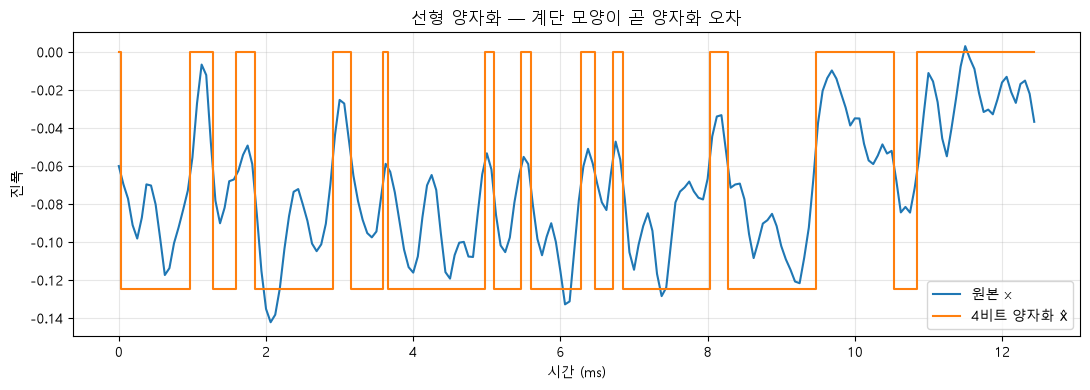

In [37]:
# 양자화 계단을 눈으로 확인 (교재 2.1.4 그림과 같은 형태)
start = 1.0
dur = 0.2
bits = 4
seg = y[int(start*sr):int(start*sr+dur*1000)]
t_ms = np.arange(len(seg)) / sr * 1000

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_ms, seg, label="원본 x", lw=1.5)
ax.step(t_ms, linear_quantize(seg, bits), where="mid", label=f"{bits}비트 양자화 x̂", lw=1.5)
ax.set(title="선형 양자화 — 계단 모양이 곧 양자화 오차", xlabel="시간 (ms)", ylabel="진폭")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 로그 양자화 (뮤법칙 mu-law)

In [39]:
# 8비트 선형 vs 8비트 뮤-법칙 비교
y_lin8 = linear_quantize(y, 4)

y_mu   = librosa.mu_compress(y, mu=255, quantize=True)   # 8비트 정수로 압축
y_mu8  = librosa.mu_expand(y_mu,  mu=255, quantize=True) # 다시 복원

print("── 신호 전체 기준 ──")
print("  8비트 선형    SNR = %6.2f dB" % snr_db(y, y_lin8))
print("  8비트 뮤-법칙 SNR = %6.2f dB" % snr_db(y, y_mu8))

# 진폭이 작은 구간(조용한 부분)만 따로 떼어 비교해 봅시다
amp = np.abs(y)
quiet = (amp > 0) & (amp < np.percentile(amp[amp > 0], 30))
print("\n── 조용한 구간(하위 30%)만 기준 ──")
print("  8비트 선형    SNR = %6.2f dB" % snr_db(y[quiet], y_lin8[quiet]))
print("  8비트 뮤-법칙 SNR = %6.2f dB  ← 뮤-법칙의 진짜 이점" % snr_db(y[quiet], y_mu8[quiet]))
print("\n뮤-법칙 압축 결과의 값 범위:", y_mu.min(), "~", y_mu.max(), "(8비트 정수)")

display(Audio(data=y_lin8, rate=sr))
display(Audio(data=y_mu8,  rate=sr))

── 신호 전체 기준 ──
  8비트 선형    SNR =  12.56 dB
  8비트 뮤-법칙 SNR =  33.70 dB

── 조용한 구간(하위 30%)만 기준 ──
  8비트 선형    SNR =   0.00 dB
  8비트 뮤-법칙 SNR =  31.16 dB  ← 뮤-법칙의 진짜 이점

뮤-법칙 압축 결과의 값 범위: -122 ~ 110 (8비트 정수)


## 윈도우 함수 모양과 스펙트럼

윈도우 길이 : 400 샘플 = 25.0 ms
스텝(hop)   : 160 샘플 = 10.0 ms
오버랩      : 60 %
주파수 해상도: 31.2 Hz/bin,  bin 개수 = 257


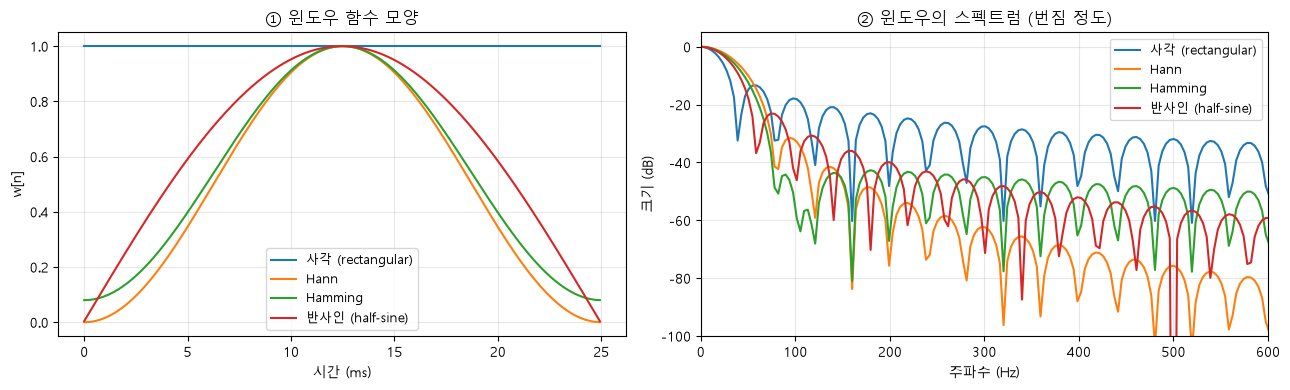

In [40]:
# 이 노트북 전체에서 쓸 분석 파라미터 (교재 2.4.3 권장값)
FRAME_LEN = 400    # 25 ms  @16 kHz
HOP_LEN   = 160    # 10 ms  @16 kHz  → 오버랩 60%
N_FFT     = 512    # 400을 담을 수 있는 2의 거듭제곱 (나머지는 0으로 채움 = 영 확장)

print(f"윈도우 길이 : {FRAME_LEN} 샘플 = {FRAME_LEN/sr*1000:.1f} ms")
print(f"스텝(hop)   : {HOP_LEN} 샘플 = {HOP_LEN/sr*1000:.1f} ms")
print(f"오버랩      : {(1-HOP_LEN/FRAME_LEN)*100:.0f} %")
print(f"주파수 해상도: {sr/N_FFT:.1f} Hz/bin,  bin 개수 = {N_FFT//2+1}")

L = FRAME_LEN
windows = {
    "사각 (rectangular)": np.ones(L),
    "Hann":               sps.get_window("hann",    L, fftbins=True),
    "Hamming":            sps.get_window("hamming", L, fftbins=True),
    "반사인 (half-sine)": np.sin(np.pi * (np.arange(L) + 0.5) / L),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, w in windows.items():
    axes[0].plot(np.arange(L)/sr*1000, w, label=name)
    W = np.abs(np.fft.rfft(w, n=4096))
    W_db = 20*np.log10(W/W.max() + 1e-12)
    axes[1].plot(np.fft.rfftfreq(4096, 1/sr), W_db, label=name)

axes[0].set(title="① 윈도우 함수 모양", xlabel="시간 (ms)", ylabel="w[n]")
axes[1].set(title="② 윈도우의 스펙트럼 (번짐 정도)", xlabel="주파수 (Hz)",
            ylabel="크기 (dB)", xlim=(0, 600), ylim=(-100, 5))
for a in axes: a.legend(fontsize=9); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 프레이밍 (윈도잉 + 이동)

frames.shape = (400, 398)  → (윈도우 길이, 프레임 개수)
공식으로 계산한 프레임 개수: 398


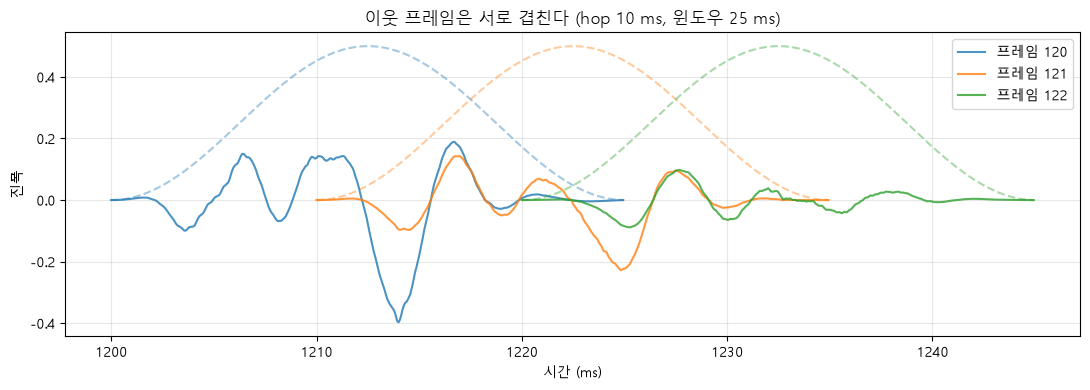

In [44]:
frames = librosa.util.frame(y, frame_length=FRAME_LEN, hop_length=HOP_LEN)
print("frames.shape =", frames.shape, " → (윈도우 길이, 프레임 개수)")

# 교재 2.2.1의 길이 공식과 대조해 봅시다
n_frames = 1 + (len(y) - FRAME_LEN) // HOP_LEN
print("공식으로 계산한 프레임 개수:", n_frames)

w = sps.get_window("hann", FRAME_LEN, fftbins=True)
frames_win = frames * w[:, np.newaxis]     # 각 열(프레임)에 윈도우를 곱함 (브로드캐스팅)

# 이웃한 세 프레임이 어떻게 겹치는지 그림으로
idx = 120
fig, ax = plt.subplots(figsize=(11, 4))
for k, color in zip([idx, idx+1, idx+2], ["C0", "C1", "C2"]):
    t0 = k * HOP_LEN / sr * 1000
    t  = t0 + np.arange(FRAME_LEN)/sr*1000
    ax.plot(t, frames_win[:, k] + 0, color=color, alpha=.8, label=f"프레임 {k}")
    ax.plot(t, w * 0.5, color=color, ls="--", alpha=.4)
ax.set(title="이웃 프레임은 서로 겹친다 (hop 10 ms, 윈도우 25 ms)",
       xlabel="시간 (ms)", ylabel="진폭")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()